# WEDINOS Scraper

Tutorials:
[Real Python](https://realpython.com/beautiful-soup-web-scraper-python/#dynamic-websites) 

## Imports

In [2]:
# Dynamic Scraper for WEDINOS Data
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Single page scraper for WEDINOS Data
import requests
from bs4 import BeautifulSoup
import json
import re, html
import os

# Other imports
import time
import pandas as pd
import folium
from folium import plugins
import pgeocode
nomi = pgeocode.Nominatim('gb')
import numpy as np
from matplotlib.pyplot import subplots

In [3]:
benzo_substring_list = ['zepine', 'zolam', 'zepoxide', 'zepam', 'benzo','azapine', 'blues', 'zapam',
                        #generic
                        'diaze', 'MSJ', 'daizepam', 'diaepam', 'diaezpam', 'bensedin', 'valium', 'valum', 'msj', 'martin dcw', 'martin dow',
                        #vallies
                        'xanax', 'xanac', 
                        #clonazepam
                        'clonaz', 'klonapin', 'ksalol', 'ksol', 'rivotril',
                        #prodrugs
                        'zafone']
diazepam_substring_list = ['diaze', 'MSJ', 'daizepam', 'diaepam', 'diaezpam', 'bensedin', 'valium', 'valum', 'msj', 'martin dcw', 'martin dow']
alprazolam_substring_list = ['alprazolam', 'xanax', 'xanac', 'alpraz', 'xanx']
clonazepam_substring_list = ['clonazepam', 'klonopin', 'klonapin', 'ksalol', 'ksol', 'rivotril']
nitazene_substring_list = ['nitazene', 'nitazepipne', 'nitazepyne', 'metonitazene', 'metonitazepine', 'metonitazepyne', 'metonitazepipne']

### Single page

In [ ]:
cwd = os.getcwd() 

In [3]:
URL = "https://www.wedinos.org/sample-results"
page = requests.get(URL)

#print(page.text)
soup = BeautifulSoup(page.content, "html.parser")
alerts = soup.find_all("div", class_="alert alert-danger")
len(alerts)

20

In [3]:
data = []
for alert in alerts:
    if "The sample was not analysed" not in str(alert):
        tag_re = re.compile(r'(<!--.*?-->|<[^>]*>)')
        code = str(alert).split('<span style="font-size: 1.4em; font-weight: 700">',1)[1].split('</span>',1)[0]
        date_received = str(alert).split('Date Received: <span style="color: black">',1)[1].split('</span>',1)[0]
        postcode = str(alert).split('Postcode: <span style="color: black">',1)[1].split(' - </span>',1)[0]
        intent = str(alert).split('Purchase Intent: <span style="color: black">',1)[1].split('</span>',1)[0]
        label = str(alert).split('Package Label: <span style="color: black">',1)[1].split('</span>',1)[0]
        colour = str(alert).split('Sample Colour: <span style="color: black">',1)[1].split('</span>',1)[0]
        form = str(alert).split('Sample Form: <span style="color: black">',1)[1].split('</span>',1)[0]
        consumption_method = str(alert).split('Consumption Method: <span style="color: black">',1)[1].split('</span>',1)[0]
        effects = str(alert).split('Self-Reported Effects: <span style="color: black">',1)[1].split('</span>',1)[0]
        major = tag_re.sub('', str(alert).split('Sample Upon Analysis (Major): <span style="color: black">',1)[1].split('</span>',1)[0])
        minor = str(alert).split('Sample Upon Analysis (Minor): <span style="color: black">',1)[1].split('</span>',1)[0]
        print(f"{postcode}: Sold as {intent} ({label}), was actually {major}.")
        myAlertData = {
            "date_received": date_received,
            "postcode": postcode,
            "intent": intent,
            "label": label,
            "colour": colour,
            "form": form,
            "consumption_method": consumption_method,
            "effects": effects,
            "major": major,
            "minor": minor
        }
        data.append({code: myAlertData})

CF10: Sold as Pregabalin (Signature double), was actually Pregabalin.
LE12: Sold as Alprazolam (Rlam), was actually Alprazolam.
TR25: Sold as heroin (Not Stated), was actually Heroin, Noscapine, 6-MAM, 6-Acetylcodeine.
CH1: Sold as Xanax (Tehran Darou Alprazolam), was actually Alprazolam.
W5: Sold as Ketamine (Not Stated), was actually Ketamine.
N1: Sold as MDMA (Not Stated), was actually MDMA.
CF10: Sold as Unknown (Not Stated), was actually Cocaine.
TF9: Sold as MDMA (Not Stated), was actually MDMA.
N1: Sold as MDMA (Not Stated), was actually MDMA.
KT3: Sold as Valium (Valium Diazepam), was actually Diazepam.
DL78: Sold as Diazepam (Valium), was actually Diazepam.
AB11: Sold as Crack cocaine (Not Stated), was actually Cocaine, Phenacetin.
LE12: Sold as Diazepam (Elipam Elikem), was actually Diazepam.
SW19: Sold as CK calvin klein coke +ketamine (Not Stated), was actually MDMA, Ketamine, Cocaine, Levamisole.
TF9: Sold as Cocaine (Not Stated), was actually Cocaine.
G42: Sold as Heroin 

In [4]:
data

[{'000233645': {'date_received': '27 Mar 2025',
   'postcode': 'CF10',
   'intent': 'Pregabalin',
   'label': 'Signature double',
   'colour': 'White',
   'form': 'Capsule',
   'consumption_method': 'Oral',
   'effects': 'Relaxed, Memory Loss, Loss of consciousness',
   'major': 'Pregabalin',
   'minor': ''}},
 {'W063091': {'date_received': '27 Mar 2025',
   'postcode': 'LE12',
   'intent': 'Alprazolam',
   'label': 'Rlam',
   'colour': 'White',
   'form': 'Tablet',
   'consumption_method': 'Not Stated',
   'effects': 'Not Stated',
   'major': 'Alprazolam',
   'minor': ''}},
 {'W063231': {'date_received': '27 Mar 2025',
   'postcode': 'TR25',
   'intent': 'heroin',
   'label': 'Not Stated',
   'colour': 'Brown',
   'form': 'Powder',
   'consumption_method': 'Not Stated',
   'effects': 'Not Stated',
   'major': 'Heroin, Noscapine, 6-MAM, 6-Acetylcodeine',
   'minor': '<a data-target="#myModal" data-toggle="modal" onclick="loadiframe(\'material.php?id=00530\')" style="color: black; text-

In [ ]:
save = input("Save to wedinos_data.json? (y/n): ")
if save.lower() == 'y':
    # Save the data to a JSON file
    with open('data/wedinos_data.json', 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

## Dynamic scraping

In [2]:
driver = webdriver.Chrome()
driver.get("https://wedinos.org/sample-results")

current_page = 0
max_pages = 63 #367 was number of pages for 1 Jan to 4 Dec 2024, 250+21+28+8 for Jan-Aug and Sept 2025
all_pages = []

while current_page < max_pages:
    try:
        # After loading all items, scrape the data
        all_pages.append(driver.page_source)
            
        load_more_button = driver.find_element(By.XPATH, "//a[text()='Next']")
        load_more_button.click()
        time.sleep(3)  # Give time for content to load
        current_page += 1
    except:
        break

driver.quit()

In [3]:
all_alerts = []
for page in all_pages:
    soup = BeautifulSoup(page, "html.parser")
    alerts = soup.find_all("div", class_="alert alert-danger")
    #all_alerts.append(alerts)
    for alert in alerts:
        try:
            tag_re = re.compile(r'(<!--.*?-->|<[^>]*>)')
            code = str(alert).split('<span style="font-size: 1.4em; font-weight: 700">',1)[1].split('</span>',1)[0]
            date_received = str(alert).split('Date Received: <span style="color: black">',1)[1].split('</span>',1)[0]
            postcode = str(alert).split('Postcode: <span style="color: black">',1)[1].split(' - </span>',1)[0]
            intent = str(alert).split('Purchase Intent: <span style="color: black">',1)[1].split('</span>',1)[0]
            label = str(alert).split('Package Label: <span style="color: black">',1)[1].split('</span>',1)[0]
            colour = str(alert).split('Sample Colour: <span style="color: black">',1)[1].split('</span>',1)[0]
            form = str(alert).split('Sample Form: <span style="color: black">',1)[1].split('</span>',1)[0]
            consumption_method = str(alert).split('Consumption Method: <span style="color: black">',1)[1].split('</span>',1)[0]
            effects = str(alert).split('Self-Reported Effects: <span style="color: black">',1)[1].split('</span>',1)[0]
            major = tag_re.sub('', str(alert).split('Sample Upon Analysis (Major): <span style="color: black">',1)[1].split('</span>',1)[0])
            minor = tag_re.sub('', str(alert).split('Sample Upon Analysis (Minor): <span style="color: black">',1)[1].split('</span>',1)[0])
            print(f"{postcode}: Sold as {intent} ({label}), was actually {major}.")
            myAlertData = {
                "date_received": date_received,
                "postcode": postcode,
                "intent": intent,
                "label": label,
                "colour": colour,
                "form": form,
                "consumption_method": consumption_method,
                "effects": effects,
                "major": major,
                "minor": minor
            }
            all_alerts.append({code: myAlertData})
        except Exception as e:
            print(f"Error processing alert: {e}")
            pass

EH52: Sold as DIAZEPAM (10MG) (STRIP OF 10 WITH VALIUM 10MG WRITTEN ON THE STRIP), was actually Diazepam.
ME4: Sold as introconazole (itradila 200), was actually No Active Component Identified.
MK18: Sold as ZOPICLONE (NOT LABELLED), was actually Zopiclone.
MK18: Sold as QUAALUDE (NOT LABELLED), was actually Methoxyqualone.
NN11: Sold as ZOPICLONE (ZOPICLONE), was actually Zopiclone.
AB24: Sold as KETAMINE (Not Stated), was actually Ketamine.
BN9: Sold as 2CB (Not Stated), was actually 2C-B.
NE31: Sold as DIAZEPAM (DIAZEPAM), was actually Diazepam.
EH54: Sold as COCAINE (NO LABEL), was actually Cocaine.
EX48: Sold as ECSTASY MDMA (Not Stated), was actually MDMA.
EH15: Sold as HEROIN (Not Stated), was actually Paracetamol, Caffeine, Noscapine, Etonitazene, Heroin.
BT47: Sold as SPEED (NOT LABELLED), was actually Caffeine, Amphetamine.
FK2: Sold as DIAZEPAM (DIAZEPAM), was actually Ethylbromazolam.
KY12: Sold as NITRAZEPAM (NITRAZEPAM), was actually Nitrazepam.
ML6: Sold as DISULFIRAM (N

In [4]:
for a in all_alerts:
    print(a)

{'W073677': {'date_received': '13 Feb 2026', 'postcode': 'SA1', 'intent': 'PREGABALIN', 'label': 'PREGABALIN', 'colour': 'White, Red', 'form': 'Capsule', 'consumption_method': 'Not Stated', 'effects': 'Relaxed', 'major': 'Pregabalin', 'minor': ''}}
{'W073678': {'date_received': '13 Feb 2026', 'postcode': 'SA1', 'intent': 'XANEX', 'label': 'XANEX', 'colour': 'White', 'form': 'Tablet', 'consumption_method': 'Not Stated', 'effects': 'Relaxed', 'major': 'Ethylbromazolam', 'minor': ''}}
{'W073842': {'date_received': '13 Feb 2026', 'postcode': 'G83', 'intent': 'zopiclone', 'label': 'zopiclone TEVA', 'colour': 'White', 'form': 'Tablet', 'consumption_method': 'Not Stated', 'effects': 'Not Stated', 'major': 'Zopiclone', 'minor': ''}}
{'W073846': {'date_received': '13 Feb 2026', 'postcode': 'CV34', 'intent': 'viagra', 'label': 'food supplement ', 'colour': 'Blue', 'form': 'Tablet', 'consumption_method': 'Oral', 'effects': 'Not Stated', 'major': 'Sildenafil', 'minor': ''}}
{'W073855': {'date_rece

In [ ]:
with open('data/wedinos-alerts-240126-100326.json', 'w', encoding='utf-8') as f:
    json.dump(all_alerts, f, ensure_ascii=False, indent=4)

In [5]:
save_alerts = input('Do you want to save the alerts to a file? (y/n): ')
if save_alerts == 'y':
    alerts_name = input('Enter the name of the file to save the alerts to: ')
    with open('data/'+alerts_name+'.json', 'w', encoding='utf-8') as f:
        json.dump(all_alerts, f, ensure_ascii=False, indent=4)
#with open('wedinos_alerts_2024.json', 'w', encoding='utf-8') as f:
    #json.dump(all_alerts, f, ensure_ascii=False, indent=4)

In [ ]:
open_alerts = input('Do you want to open a saved alerts file? (y/n): ')
if open_alerts == 'y':
    alerts_name = input('Enter the name of the json file to open: ')
    with open('data/'+alerts_name+'.json', 'r', encoding='utf-8') as f:
        all_alerts = json.load(f)
        print(len(all_alerts))
#with open('wedinos_alerts_2024.json', 'r', encoding='utf-8') as f:
    #all_alerts = json.load(f)
    #print(len(all_alerts))

1143


In [6]:
for alert in all_alerts:
    for i in alert:
        if ('nitazene' in alert[i]['major']) or ('nitazepipne' in alert[i]['major']) or ('nitazepyne' in alert[i]['major']):
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        elif ('nitazene' in alert[i]['minor']) or ('nitazepipne' in alert[i]['minor']) or ('nitazepyne' in alert[i]['minor']):
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        elif ('nitazene' in alert[i]['intent']) or ('nitazepipne' in alert[i]['intent']) or ('nitazepyne' in alert[i]['intent']):
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        elif ('methazene' in alert[i]['major']) or ('methazene' in alert[i]['minor']) or ('methazene' in alert[i]['intent']):
            print(i,'!!!!!!!')

W073845 13 Feb 2026 G83 – Sold as HEROIN , tested as Paracetamol, Caffeine, Noscapine, Heroin, Etonitazene with 6-MAM, Papaverine
W073552 06 Feb 2026 WF2 – Sold as heroin , tested as N-pyrrolidino protonitazene, Paracetamol, N-propionitrile chlorphine, Heroin, Medetomidine, Caffeine, Noscapine with N-desethylprotonitazene, Etodezitramide, 6-MAM, Papaverine
W073006 03 Feb 2026 ST87 – Sold as Oxycodone , tested as AB-MDMSBA with Metonitazene
W069103 28 Jan 2026 EH6 – Sold as heroin , tested as Paracetamol, Noscapine, Caffeine, Heroin with Metonitazene, 6-Acetylcodeine, Papaverine, 6-MAM
W073102 26 Jan 2026 BN25 – Sold as Valium , tested as Metonitazene, Bromazolam  
W073075 26 Jan 2026 EH48 – Sold as Heroin , tested as Noscapine, Paracetamol, Diazepam, Caffeine, Etonitazene, Heroin with 6-MAM, Papaverine
000234134 28 Jan 2026 NP20 – Sold as Heroin , tested as xylazine, Metonitazene, Phenacetin, Caffeine, Paracetamol with Protonitazene, 6-MAM, Noscapine, Cocaine, Heroin, 6-Acetylcodeine, 

## Postcodes

In [15]:
#col = list(myAlertData.keys())
col=["date_received","postcode","intent","label","colour","form","consumption_method","effects","major","minor"]
col.append('latitude')
col.append('longitude')
print(col)

['date_received', 'postcode', 'intent', 'label', 'colour', 'form', 'consumption_method', 'effects', 'major', 'minor', 'latitude', 'longitude']


In [16]:
str(nomi.query_postal_code('TQ46')['latitude'])

'nan'

In [17]:
##### BENZO, NOT NITAZENE ####
df_benzo = pd.DataFrame(columns=col)
for alert in all_alerts:
    for i in alert:
        if ('zepine' in alert[i]['major'].lower()) or ('zepine' in alert[i]['minor'].lower()) or ('zepine' in alert[i]['intent'].lower()) or ('zafone' in alert[i]['major'].lower()) or ('zafone' in alert[i]['minor'].lower()) or ('zafone' in alert[i]['intent'].lower()) or ('zolam' in alert[i]['major'].lower()) or ('zolam' in alert[i]['minor'].lower()) or ('zolam' in alert[i]['intent'].lower()) or ('zepoxide' in alert[i]['major'].lower()) or ('zepoxide' in alert[i]['minor'].lower()) or ('zepoxide' in alert[i]['intent'].lower()) or ('zepam' in alert[i]['major'].lower()) or ('zepam' in alert[i]['minor'].lower()) or ('zepam' in alert[i]['intent'].lower()) or ('xanax' in alert[i]['intent'].lower()) or ('diaze' in alert[i]['intent'].lower()) or ('benzo' in alert[i]['intent'].lower()) or ('MSJ' in alert[i]['intent'].lower()):
            try:
                if str(nomi.query_postal_code(alert[i]['postcode'])['latitude']) != 'nan':
                    lat, long = float(nomi.query_postal_code(alert[i]['postcode'])['latitude']), float(nomi.query_postal_code(alert[i]['postcode'])['longitude'])
                else:
                    pcode = alert[i]['postcode'][:3]
                    lat, long = float(nomi.query_postal_code(pcode)['latitude']), float(nomi.query_postal_code(pcode)['longitude'])
            except:
                print(f"Error with postcode {alert[i]['postcode']}, using default coordinates.")
                lat, long = 0, 0 # Alternative if this messes up the map: Default to London coordinates if postcode lookup fails 51.509865, -0.118092

            alert[i]['latitude'] = lat
            alert[i]['longitude'] = long
            df_benzo.loc[i] = pd.Series(alert[i])
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        

W073828 10 Mar 2026 EH52 – Sold as DIAZEPAM (10MG) , tested as Diazepam  
W074683 10 Mar 2026 NE31 – Sold as DIAZEPAM , tested as Diazepam  
W074693 10 Mar 2026 FK2 – Sold as DIAZEPAM , tested as Ethylbromazolam  
W074677 10 Mar 2026 KY12 – Sold as NITRAZEPAM , tested as Nitrazepam  
W074701 10 Mar 2026 AL71 – Sold as VALIUM , tested as Diazepam  
W074713 10 Mar 2026 N1 – Sold as XANAX , tested as Bromazolam  
W074668 10 Mar 2026 CW9 – Sold as DIAZEPAM , tested as Diazepam  
W074684 10 Mar 2026 B240 – Sold as CLONAZEPAM ENURAXPHARM 2MG , tested as Clonazepam  
000234140 10 Mar 2026 NP23 – Sold as DIAZEPAM , tested as Diazepam  
000234149 10 Mar 2026 NP20 – Sold as Not Stated , tested as Diazepam  
W074662 10 Mar 2026 HP13 – Sold as DIAZEPAM , tested as Diazepam  
W074651 10 Mar 2026 SA16DR – Sold as DIAZEPAM , tested as Ethylbromazolam  
W074678 10 Mar 2026 NG10 – Sold as XANAX , tested as Ethylbromazolam  
000235587 10 Mar 2026 NP12 – Sold as DIAZEPAM , tested as Diazepam  
W074661 10

In [18]:
for idx, row in df_benzo.iterrows():
    if "W072830" in idx:
        print(row)

In [19]:
for alert in all_alerts:
    for i in alert:
        if "072830" in i:
            print(alert)
            if "diaze" in alert[i]['intent'].lower():
                print('benzo')

In [20]:
if "072830" in df_benzo.index:
    print('072830')

In [21]:
##### NITAZENES ####
#all_alerts = json.load(open('wedinos_alerts_2024.json')) # remove if you want to scrape the data again
df = pd.DataFrame(columns=col)
for alert in all_alerts:
    for i in alert:
        if ('nitazene' in alert[i]['major'].lower()) or ('nitazepipne' in alert[i]['major'].lower()) or ('nitazepyne' in alert[i]['major'].lower()) or ('nitazene' in alert[i]['minor'].lower()) or ('nitazepipne' in alert[i]['minor'].lower()) or ('nitazepyne' in alert[i]['minor'].lower()) or ('nitazene' in alert[i]['intent'].lower()) or ('nitazepipne' in alert[i]['intent'].lower()) or ('nitazepyne' in alert[i]['intent'].lower()):
            try:
                if str(nomi.query_postal_code(alert[i]['postcode'])['latitude']) != 'nan':
                    lat, long = float(nomi.query_postal_code(alert[i]['postcode'])['latitude']), float(nomi.query_postal_code(alert[i]['postcode'])['longitude'])
                else:
                    pcode = alert[i]['postcode'][:3]
                    lat, long = float(nomi.query_postal_code(pcode)['latitude']), float(nomi.query_postal_code(pcode)['longitude'])
            except:
                print(f"Error with postcode {alert[i]['postcode']}, using default coordinates.")
                lat, long = 51.509865, -0.118092 # Default to London coordinates if postcode lookup fails

            alert[i]['latitude'] = lat
            alert[i]['longitude'] = long
            df.loc[i] = pd.Series(alert[i])
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        

W069097 10 Mar 2026 EH15 – Sold as HEROIN , tested as Paracetamol, Caffeine, Noscapine, Etonitazene, Heroin with 6-MAM, Papaverine
W069096 10 Mar 2026 EH3 – Sold as HEROIN , tested as Noscapine, Paracetamol, Heroin, Caffeine, 6-MAM with 6-Acetylcodeine, Metonitazene, Papaverine
W074528 09 Mar 2026 EH32 – Sold as Heroin , tested as Paracetamol, Caffeine, Etonitazene, Heroin with Morphine, Papaverine
000233528 17 Feb 2026 NP20 – Sold as HEROIN , tested as xylazine with Phenacetin, Metonitazene, Paracetamol, Caffeine, Protonitazene, nitrazolam, Bromazolam, Noscapine, 6-MAM
W073845 13 Feb 2026 G83 – Sold as HEROIN , tested as Paracetamol, Caffeine, Noscapine, Heroin, Etonitazene with 6-MAM, Papaverine
W073552 06 Feb 2026 WF2 – Sold as heroin , tested as N-pyrrolidino protonitazene, Paracetamol, N-propionitrile chlorphine, Heroin, Medetomidine, Caffeine, Noscapine with N-desethylprotonitazene, Etodezitramide, 6-MAM, Papaverine
W073006 03 Feb 2026 ST87 – Sold as Oxycodone , tested as AB-MDMS

In [23]:
df_benzo_all = pd.read_csv('data/wedinos_benzo_010126-100326.csv', sep=',', encoding='utf-8', index_col=0) #010126-100326
df_nit_all = pd.read_csv('data/wedinos-nitazenes_010126-130226.csv', sep=',', encoding='utf-8', index_col=0)
#df_nit_all = pd.read_csv('data/wedinos_nitazenes_010125-031225.csv', sep=',', encoding='utf-8',index_col=0)

for idx, row in df_benzo.iterrows():
    if idx in df_benzo_all.index:
        print(f"Duplicate index found: {idx}, skipping.")
    else:
        df_benzo_all.loc[idx] = row
for idx, row in df.iterrows():
    if idx in df_nit_all.index:
        print(f"Duplicate index found: {idx}, skipping.")
    else:
        df_nit_all.loc[idx] = row

print(df_nit_all.shape, df_benzo_all.shape)
df_benzo_all.head()

Duplicate index found: W073828, skipping.
Duplicate index found: W074683, skipping.
Duplicate index found: W074693, skipping.
Duplicate index found: W074677, skipping.
Duplicate index found: W074701, skipping.
Duplicate index found: W074713, skipping.
Duplicate index found: W074668, skipping.
Duplicate index found: W074684, skipping.
Duplicate index found: 000234140, skipping.
Duplicate index found: 000234149, skipping.
Duplicate index found: W074662, skipping.
Duplicate index found: W074651, skipping.
Duplicate index found: W074678, skipping.
Duplicate index found: 000235587, skipping.
Duplicate index found: W074661, skipping.
Duplicate index found: W074658, skipping.
Duplicate index found: W074567, skipping.
Duplicate index found: W074435, skipping.
Duplicate index found: W074628, skipping.
Duplicate index found: W074633, skipping.
Duplicate index found: W074617, skipping.
Duplicate index found: W074622, skipping.
Duplicate index found: W074632, skipping.
Duplicate index found: W0745

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W073828,10 Mar 2026,EH52,DIAZEPAM (10MG),STRIP OF 10 WITH VALIUM 10MG WRITTEN ON THE STRIP,Blue,Tablet,Oral,"Increased Energy, Increased Confidence, Relaxe...",Diazepam,NaN,55.935800,-3.488262
W074683,10 Mar 2026,NE31,DIAZEPAM,DIAZEPAM,Blue,Tablet,Oral,Relaxed,Diazepam,NaN,54.973000,-1.515500
W074693,10 Mar 2026,FK2,DIAZEPAM,DIAZEPAM,White,Tablet,Oral,Relaxed,Ethylbromazolam,NaN,56.017173,-3.755473
W074677,10 Mar 2026,KY12,NITRAZEPAM,NITRAZEPAM,White,Tablet,Oral,Relaxed,Nitrazepam,NaN,56.087095,-3.539235
W074701,10 Mar 2026,AL71,VALIUM,ZEPAM 10MG,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed",Diazepam,NaN,51.796900,-0.187100


In [25]:
df_benzo_all

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W073828,10 Mar 2026,EH52,DIAZEPAM (10MG),STRIP OF 10 WITH VALIUM 10MG WRITTEN ON THE STRIP,Blue,Tablet,Oral,"Increased Energy, Increased Confidence, Relaxe...",Diazepam,NaN,55.935800,-3.488262
W074683,10 Mar 2026,NE31,DIAZEPAM,DIAZEPAM,Blue,Tablet,Oral,Relaxed,Diazepam,NaN,54.973000,-1.515500
W074693,10 Mar 2026,FK2,DIAZEPAM,DIAZEPAM,White,Tablet,Oral,Relaxed,Ethylbromazolam,NaN,56.017173,-3.755473
W074677,10 Mar 2026,KY12,NITRAZEPAM,NITRAZEPAM,White,Tablet,Oral,Relaxed,Nitrazepam,NaN,56.087095,-3.539235
W074701,10 Mar 2026,AL71,VALIUM,ZEPAM 10MG,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed",Diazepam,NaN,51.796900,-0.187100
...,...,...,...,...,...,...,...,...,...,...,...,...
000234331,03 Dec 2025,CF11,Clonazepam,Clonazepam,White,Tablet,Not Stated,Relaxed,Clonazepam,,51.480000,-3.180000
W071538,03 Dec 2025,GL54,Clonazepam,Rivotril Galenika,White,Tablet,Oral,Nausea,Paracetamol,Bromazolam,51.887246,-1.860921
W071610,03 Dec 2025,TW7,Alprazolam,Alprax XR2 Alprazolam,"White, Yellow",Tablet,Not Stated,Not Stated,Alprazolam,,51.475200,-0.342500
W071557,03 Dec 2025,NP22,Diazepam,Accord Diaezpem tabelt,Blue,Tablet,Not Stated,Not Stated,Ethylbromazolam,,51.772500,-3.246800


In [22]:
wikiurl = 'https://en.wikipedia.org/wiki/List_of_orphine_opioids#Table_of_Orphines'
wiki_tables = pd.read_html(wikiurl)

ImportError: Missing optional dependency 'lxml'.  Use pip or conda to install lxml.

In [15]:
df_benzo_2026 = df_benzo_all[df_benzo_all['date_received'].str.contains("2026")]
df_benzo_2026

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W073828,10 Mar 2026,EH52,DIAZEPAM (10MG),STRIP OF 10 WITH VALIUM 10MG WRITTEN ON THE STRIP,Blue,Tablet,Oral,"Increased Energy, Increased Confidence, Relaxe...",Diazepam,NaN,55.935800,-3.488262
W074683,10 Mar 2026,NE31,DIAZEPAM,DIAZEPAM,Blue,Tablet,Oral,Relaxed,Diazepam,NaN,54.973000,-1.515500
W074693,10 Mar 2026,FK2,DIAZEPAM,DIAZEPAM,White,Tablet,Oral,Relaxed,Ethylbromazolam,NaN,56.017173,-3.755473
W074677,10 Mar 2026,KY12,NITRAZEPAM,NITRAZEPAM,White,Tablet,Oral,Relaxed,Nitrazepam,NaN,56.087095,-3.539235
W074701,10 Mar 2026,AL71,VALIUM,ZEPAM 10MG,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed",Diazepam,NaN,51.796900,-0.187100
...,...,...,...,...,...,...,...,...,...,...,...,...
W072427,05 Jan 2026,G63,HEROIN,T3-TRILOGY #3 CREAM,"Brown, Brown",Powder,Not Stated,Not Stated,"Heroin, Noscapine, 6-MAM, Diazepam, 6-Acetylco...","Phenacetin, Papaverine, Morphine",56.036544,-4.350012
100004525,05 Jan 2026,EX32,DIAZEPAM 10MG,BENSEDIN 10MG (DIAZEPAM),White,Tablet,Not Stated,"Empathy, Relaxed",Diazepam,,51.073640,-3.978230
W072449,08 Jan 2026,SG14,Lorazepam 2mg,Lorazepam/nerodelm,Yellow,Tablet,Not Stated,Not Stated,"Citalopram, Lorazepam",,51.811775,-0.117050
W072428,05 Jan 2026,G63,ALPRAZOLAM (XANAX-4MG),4MG XANAX,White,Tablet,Not Stated,Not Stated,Ethylbromazolam,,56.036544,-4.350012


In [24]:
save_table = input('Do you want to save the table? (y/n): ')
if save_table == 'y':
    table_name = input('Enter the name of the table: ')
    if ('benzo' in table_name):
        df_benzo_all.to_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8')
    else:
        df_nit_all.to_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8')
    #df.to_csv('wedinos_alerts_2024.csv', sep='\t', encoding='utf-8')
df

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W069097,10 Mar 2026,EH15,HEROIN,Not Stated,Brown,Powder,Smoked,"Nausea, Vomiting, Memory Loss","Paracetamol, Caffeine, Noscapine, Etonitazene,...","6-MAM, Papaverine",55.948033,-3.112067
W069096,10 Mar 2026,EH3,HEROIN,Not Stated,Brown,Powder,Intravenous,"Memory Loss, Confusion, Loss of consciousness","Noscapine, Paracetamol, Heroin, Caffeine, 6-MAM","6-Acetylcodeine, Metonitazene, Papaverine",55.9521,-3.1965
W074528,09 Mar 2026,EH32,Heroin,Not Stated,Brown,Powder,Not Stated,Relaxed,"Paracetamol, Caffeine, Etonitazene, Heroin","Morphine, Papaverine",55.978114,-2.919357
000233528,17 Feb 2026,NP20,HEROIN,Not Stated,Brown,Powder,Not Stated,Not Stated,xylazine,"Phenacetin, Metonitazene, Paracetamol, Caffein...",51.5877,-2.9984
W073845,13 Feb 2026,G83,HEROIN,Not Stated,Brown,Powder,Not Stated,Not Stated,"Paracetamol, Caffeine, Noscapine, Heroin, Eton...","6-MAM, Papaverine",56.039892,-4.600658
W073552,06 Feb 2026,WF2,heroin,Not Stated,Brown,Powder,Not Stated,Not Stated,"N-pyrrolidino protonitazene, Paracetamol, N-pr...","N-desethylprotonitazene, Etodezitramide, 6-MAM...",53.66534,-1.51568
W073006,03 Feb 2026,ST87,Oxycodone,v48/12,Blue,Tablet,Oral,Relaxed,AB-MDMSBA,Metonitazene,53.115657,-2.169114
W069103,28 Jan 2026,EH6,heroin,Heroin,"Grey, Brown",Plant Matter,Smoked,"No Effect, Increased Energy, Increased Confide...","Paracetamol, Noscapine, Caffeine, Heroin","Metonitazene, 6-Acetylcodeine, Papaverine, 6-MAM",55.9617,-3.1844
W073102,26 Jan 2026,BN25,Valium,Martin dow,Blue,Tablet,Oral,Relaxed,"Metonitazene, Bromazolam",,50.7807,0.095625
W073075,26 Jan 2026,EH48,Heroin,Not Stated,Brown,Powder,Snort / Sniff,Overdose,"Noscapine, Paracetamol, Diazepam, Caffeine, Et...","6-MAM, Papaverine",55.913057,-3.674629


In [ ]:
# Import table
open_table = input('Do you want to open a saved CSV file? (y/n): ')
if open_table == 'y':
    table_name = input('Enter the name of the .csv file:')
    if ('benzo' in table_name):
        df_benzo_all = pd.read_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8', index_col=0)
        df_benzo['minor'] = df_benzo['minor'].fillna('')
    else:
        df_all = pd.read_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8', index_col=0)
        #df['minor'] = df['minor'].fillna('')

In [12]:
df = pd.read_csv('data/wedinos_nitazenes_2025.csv', sep=',', encoding='utf-8', index_col=0)
df_benzo = pd.read_csv('data/wedinos_benzos_2025.csv', sep=',', encoding='utf-8', index_col=0)
df_benzo['minor'] = df_benzo['minor'].fillna('')

## Plot map

In [25]:
def counterfeit_map(df, filename, intent_list, result_list, include_all=False, save=False):
    # Initialize map
    m = folium.Map(
        location=[53.989955, -3.151694],  # center of the map
        zoom_start=5,  # dezoom
        tiles='cartodb positron'  # background style
    )
    cluster = plugins.MarkerCluster(name=intent_list[0]).add_to(m)
    cluster_2 = plugins.MarkerCluster(name=result_list[0]).add_to(m)
    # Add all the individual earthquakes to the map
    for idx, row in df.iterrows():
        if type(row['minor']) == float:
            row['minor'] = str('')
        if len(row['minor']) ==0:
            #popup = f"{row['postcode']} – Sold as {row['intent']}, tested as {row['major']}"
            popup = f"""
                <h1>{idx}</h1>
                <p>
                Postcode: <b>{row['postcode']}</b><br/>
                Date: <b>{row['date_received']}</b><br/>
                Sold as: <b>{row['intent']}</b><br/>
                Tested as: <b>{row['major']}</b><br/>
                </p>
                """

        else:
            #popup = f"{row['postcode']} – Sold as {row['intent']}, tested as {row['major']} with {row['minor']}"
            popup = f"""
                <h1>{idx}</h1>
                <p>
                Postcode: <b>{row['postcode']}</b><br/>
                Date: <b>{row['date_received']}</b><br/>
                Sold as: <b>{row['intent']}</b><br/>
                Tested as: <b>{row['major']}</b> with <b>{row['minor']}</b><br/>
                </p>
                """
        
        color = '#1e3d77' if any(substring in str.lower(row['intent']) for substring in intent_list) and any(substring in str.lower(row['major']) or str.lower(row['minor']) for substring in result_list) else '#ffde5b'
        try:
            if any(substring in str.lower(row['intent']) for substring in intent_list) and any(substring in str.lower(row['major']) or str.lower(row['minor']) for substring in result_list):
                folium.CircleMarker(
                    location=[row['latitude'], row['longitude']],
                    radius=15,
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.5,
                    weight=1,
                    popup=popup
                ).add_to(cluster)
            elif include_all == True:
                folium.CircleMarker(
                    location=[row['latitude'], row['longitude']],
                    radius=15,
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.5,
                    weight=1,
                    popup=popup
                ).add_to(cluster_2)
        except:
            pass
    if save:
        m.save(f'data/{filename}_map.html')
    return m

In [32]:
df_2026 = pd.read_csv('data/wedinos_benzos_010126-100326.csv', sep=',', encoding='utf-8', index_col=0)

In [33]:
counterfeit_map(df_2026,
            filename='010126-100326_tramadolbenzos',
            intent_list=alprazolam_substring_list,
            result_list=['tramadol'],
            save=True)

In [26]:
counterfeit_map(df,
                filename='2025_nitazenebenzos',
                intent_list=benzo_substring_list,
                result_list=nitazene_substring_list,
                include_all=True,
                save=True)

In [13]:
# Initialize map
m = folium.Map(
    location=[53.989955, -3.151694],  # center of the map
    zoom_start=5,  # dezoom
    tiles='cartodb positron'  # background style
)
marker_cluster = plugins.MarkerCluster(name="nitazenes").add_to(m)
benzo_cluster = plugins.MarkerCluster(name="counterfeit_benzos").add_to(m)
# Add all the individual earthquakes to the map
for idx, row in df_nit_all.iterrows():
    if type(row['minor']) == float:
        row['minor'] = str('')
    if len(row['minor']) ==0:
        #popup = f"{row['postcode']} – Sold as {row['intent']}, tested as {row['major']}"
        popup = f"""
            <h1>{idx}</h1>
            <p>
            Postcode: <b>{row['postcode']}</b><br/>
            Date: <b>{row['date_received']}</b><br/>
            Sold as: <b>{row['intent']}</b><br/>
            Tested as: <b>{row['major']}</b><br/>
            </p>
            """

    else:
        #popup = f"{row['postcode']} – Sold as {row['intent']}, tested as {row['major']} with {row['minor']}"
        popup = f"""
            <h1>{idx}</h1>
            <p>
            Postcode: <b>{row['postcode']}</b><br/>
            Date: <b>{row['date_received']}</b><br/>
            Sold as: <b>{row['intent']}</b><br/>
            Tested as: <b>{row['major']}</b> with <b>{row['minor']}</b><br/>
            </p>
            """
    
    color = '#1e3d77' if any(substring in str.lower(row['intent']) for substring in benzo_substring_list) else '#ffde5b'
    try:
        if  any(substring in str.lower(row['intent']) for substring in benzo_substring_list):
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=15,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.5,
                weight=1,
                popup=popup
            ).add_to(benzo_cluster)
        else:
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=15,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.5,
                weight=1,
                popup=popup
            ).add_to(marker_cluster)
    except:
        pass
if input('save map? (y/n): ') == 'y':
    m.save(f'data/{input('input date in DDMMYY_DDMMYY format: ')}_map.html')
m

In [12]:
m.save('data/2025_map.html')

In [42]:
save_map = input('Do you want to save the map? (y/n): ')
if save_map == 'y':
    map_name = input('Enter the name of the map: ')
    m.save(f'/{cwd}/data/{map_name}.html')

## Other calculations

In [ ]:
# Restricting date to January
df_month = df.loc[df['date_received'].str.contains('Feb')]
df_benzo_month = df_benzo.loc[df_benzo['date_received'].str.contains('Feb')]
print(df_benzo_month.shape)
df_benzo_month

(315, 12)


,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W074435,27 Feb 2026,BS5,Valium/ diazepam,diazepam/ watson lab,White,Tablet,Oral,"Relaxed, Insomnia",Bromazolam,,51.462,-2.5519
000239553,27 Feb 2026,NP22,Xanax,Not Stated,White,Tablet,Oral,Not Stated,Methylclonazepam,,51.7725,-3.2468
W074448,27 Feb 2026,B807,Clonazepam,Clonzepam/ martin dow rivotril,White,Tablet,Not Stated,Not Stated,Clonazepam,,52.27168,-1.88216
W073798,17 Feb 2026,EH7,Diazepam,Diazepam,Yellow,Tablet,Oral,No Effect,Diazepam,,55.9521,-3.1965
000236813,27 Feb 2026,CF64,Diazepam,Diazepam,White,Tablet,Oral,Relaxed,Diazepam,,51.42878,-3.21045
...,...,...,...,...,...,...,...,...,...,...,...,...
W073270,03 Feb 2026,PR4,Diazepam 10mg,Bensedin,"White, Purple",Tablet,Oral,"Euphoria, Relaxed, Breathlesness, Paranoia, Lo...",No Active Component Identified,,53.755026,-2.838754
W073271,03 Feb 2026,PR4,Diazepam 10mg,Diazpam 10mg,White,Tablet,Oral,"Euphoria, Relaxed",Ethylbromazolam,,53.755026,-2.838754
W073274,03 Feb 2026,SK23,valium,diazepam,White,Tablet,Not Stated,Not Stated,Diazepam,,53.331567,-1.944833
W073313,03 Feb 2026,E3,Xanax/ alprazolam,Not Stated,White,Tablet,Not Stated,Not Stated,"Bromazolam, Tramadol",,51.527657,-0.026571


In [ ]:
df_benzo_month.to_csv('data/wedinos_benzos_february_2026.csv', sep=',', encoding='utf-8')

In [392]:
benzo_substring_list

['zepine',
 'zolam',
 'zepoxide',
 'zepam',
 'benzo',
 'azapine',
 'blues',
 'zapam',
 'diaze',
 'MSJ',
 'daizepam',
 'diaepam',
 'diaezpam',
 'bensedin',
 'valium',
 'valum',
 'msj',
 'martin dcw',
 'martin dow',
 'xanax',
 'xanac',
 'clonaz',
 'klonapin',
 'ksalol',
 'ksol',
 'rivotril']

In [ ]:
# Note this may not work properly if using the df_all file
#df = df_nit_all.loc[df_nit_all['date_received'].str.contains('January 2026')]
df = df_month
cbenzo_count=0
cbenzo_meto_count = 0
totalnit=0
wantednit=0
unknownnit=0
print(df.shape)
df['minor'] = df['minor'].fillna('')
for idx, row in df.iterrows():
    totalnit+=1
    intentlabel = str.lower(row['intent']) + ' ' + str.lower(row['label'])
    if any(substring in intentlabel for substring in benzo_substring_list):
        cbenzo_count+=1
        if ('metonitazene' in str.lower(row['major'])) or ('metonitazene' in str.lower(str(row['minor']))):
            cbenzo_meto_count+=1
        else:
            print(row['intent'],': ',row['major'],'with',row['minor'])
    elif any(substring in intentlabel for substring in nitazene_substring_list): 
        wantednit+=1
    elif ("unknown" in intentlabel):
        print("Unknown intent/label:", row['intent'], row['label'])
        unknownnit+=1

dates = input('Enter the date range for the analysis (e.g., Jan–Aug 2025): ')
print(f"Between {dates}:") 
print(f"– {cbenzo_count} out of {totalnit} samples tested as nitazenes were sold as benzos ({100*cbenzo_count/totalnit:.1f}%)")
print(f"– {cbenzo_meto_count} out of {cbenzo_count} counterfeit benzos which contained nitazenes, contained metonitazene ({100*cbenzo_meto_count/cbenzo_count:.1f}%)")
print(f"– {wantednit} out of {totalnit} samples containing nitazenes, were sold as nitazenes ({(100*wantednit/totalnit):.1f}%)")
print(f"– {unknownnit} out of {totalnit} samples containing nitazenes, had unknown intent ({(100*unknownnit/totalnit):.1f}%)")

(4, 12)
Between 1-28 Feb 2026:
– 0 out of 4 samples tested as nitazenes were sold as benzos (0.0%)


ZeroDivisionError: division by zero

In [15]:
print(df_benzo_sept[['intent','label']].value_counts())

intent                  label                 
Diazepam                Not Stated                11
                        Diazepam                   8
diazepam                Not Stated                 4
Diazepam                Bensedin                   3
Xanax                   Not Stated                 3
                                                  ..
Diazepam                dizpam-10                  1
                        galenika Bensedin 10mg     1
                        galenika Diazepam 10mg     1
                        martin dow Valium          1
xanax 1mg (alprazolam)  ksalol alprazolam          1
Name: count, Length: 151, dtype: int64


In [ ]:
### Old – see cells below for updated analysis ###
benzos=0
unknown=0
not_benzo=0
total=0
for idx, row in df_benzo.iterrows():
    if any(substring in str.lower(row['intent']) for substring in benzo_substring_list):
        benzos+=1
    elif ('found' in str.lower(row['intent'])) or ('not stated' in str.lower(row['intent'])) or ('unknown' in str.lower(row['intent'])):
        unknown+=1
    else:
        not_benzo+=1
    total+=1

dates = input('Enter the date range for the analysis (e.g., Jan–Aug 2025): ')
print(f"Of {total} samples either sold as or containing benzos in {dates}:")
print(f"- {benzos} were sold as benzos ({100*benzos/total:.1f}%)")
print(f"- {unknown} were unknown at sale, found, or not stated ({100*unknown/total:.1f}%)")
print(f"- {not_benzo} were not sold as benzos ({100*not_benzo/total:.1f}%)")

Of 1940 samples either sold as or containing benzos in :
- 1880 were sold as benzos (96.9%)
- 19 were unknown at sale, found, or not stated (1.0%)
- 41 were not sold as benzos (2.1%)


In [16]:
df_benzo

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
000234320,12 Aug 2025,CF11,Diazepam,Teva,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed, Memor...",Diazepam,,51.480000,-3.180000
W067706,12 Aug 2025,NE66,Benzo,bensedin,White,Tablet,Not Stated,Not Stated,Diazepam,,55.419943,-1.790742
W067739,12 Aug 2025,KT4,Diazepam,galenika Bensedin,White,Tablet,Oral,Relaxed,Diazepam,,51.389950,-0.247200
W067731,12 Aug 2025,OX25,Diazepam,Diazepam,Blue,Tablet,Not Stated,Not Stated,Diazepam,,51.900000,-1.153600
W067632,12 Aug 2025,SW25,Alprazolam (xanax),Alpraolam,Green,Tablet,Not Stated,Not Stated,Alprazolam,,51.454800,-0.115800
...,...,...,...,...,...,...,...,...,...,...,...,...
W069111,25 Sep 2025,GU28,diazepam 5mg,diazepam 5mp accord blister pack,Yellow,Tablet,Not Stated,Not Stated,Diazepam,,50.982400,-0.643133
W069281,25 Sep 2025,N20,diazepam 10mg,accord diazepam 10mg,Blue,Tablet,Oral,"Relaxed, Memory Loss",Ethylbromazolam,,51.633300,-0.183320
W069297,25 Sep 2025,RG27,XANAX,Not Stated,White,Tablet,Not Stated,Not Stated,Ethylbromazolam,,51.304967,-0.951079
W069250,25 Sep 2025,SG7,DIAZEPAM,ACCORD 10MG DIAZEPAM,Blue,NaN,Not Stated,Not Stated,Diazepam,,52.011856,-0.173911


In [33]:
### New – checking if benzos were counterfeit or not
def check_benzo_status(df_benzo, dates):
    "Adds columns to a dataframe indicating if benzos were sold as benzos and if they were counterfeit or not"
    for idx, row in df_benzo.iterrows():
        if any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in benzo_substring_list):
            sold_as_benzo='1'
            try: # try-except to avoid errors with missing testing data
                if (str.lower(row['major']) in str.lower(row['intent']+' '+str.lower(row['label']))) or (str.lower(row['intent']) in str.lower(row['major'])) or (str.lower(row['label']) in str.lower(row['major'])):
                    status='not counterfeit'
                elif ('unable to identify' in str.lower(row['major'])):
                    status='inconclusive'
                # checking diazepam spellings
                elif any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in diazepam_substring_list):
                    if ('diazepam' in str.lower(row['major'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                # checking xanax spellings
                elif any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in alprazolam_substring_list):
                    if ('alprazolam' in str.lower(row['major'])):
                        status='not counterfeit'    
                    else:
                        status='counterfeit'
                # checking clonazepam spellings
                elif any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in clonazepam_substring_list):
                    if ('clonazepam' in str.lower(row['major'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                elif ('benzo' in str.lower(row['intent']+' '+str.lower(row['label']))):
                    if any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in diazepam_substring_list):
                        if ('diazepam' in str.lower(row['major'])):
                            status='not counterfeit'
                        else:
                            status='counterfeit'
                    elif any(substring in str.lower(row['major']) for substring in benzo_substring_list):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                else:
                    status='counterfeit'
                    #print(row['intent'],': ',row['major'],'with',row['minor'])
            except:
                status='inconclusive'
        else:
            sold_as_benzo='0'
        
        df_benzo.loc[idx,'sold_as_benzo'] = sold_as_benzo
        df_benzo.loc[idx,'status'] = status
    total = len(df_benzo)
    total_benzo_intent = len(df_benzo[df_benzo['sold_as_benzo'] == '1'])
    total_not_benzos = len(df_benzo[df_benzo['sold_as_benzo'] == '0'])
    total_counterfeit_benzos = len(df_benzo[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'counterfeit')])
    total_correct_benzos = len(df_benzo[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'not counterfeit')])
    unknown_benzos = len(df_benzo[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'inconclusive')])
    print(f'Between {dates},',total_benzo_intent,'out of',total,f'samples mentioning benzos were sold as benzos ({(100*total_benzo_intent/total):.1f}%), of which:')
    print('-',total_correct_benzos,f'benzos contained what they were sold as ({(100*total_correct_benzos/total_benzo_intent):.1f}%)')
    print('-',total_counterfeit_benzos,f'benzos were counterfeit ({(100*total_counterfeit_benzos/total_benzo_intent):.1f}%)')
    print('-',unknown_benzos,f'samples sold as benzos were inconclusive ({(100*unknown_benzos/total_benzo_intent):.1f}%)')
    print('-',total_not_benzos,f'samples containing benzos were not sold as benzos ({(100*total_not_benzos/total):.1f}%)')
    array = [total, total_benzo_intent, total_not_benzos, total_counterfeit_benzos, total_correct_benzos, unknown_benzos]

    return df_benzo, array

In [ ]:
df_benzo_month, benzo_jan_figures = check_benzo_status(df_benzo_month, '1–28 February 2026')
df_benzo_month

Between 1–28 February 2026, 301 out of 315 samples mentioning benzos were sold as benzos (95.6%), of which:
- 200 benzos contained what they were sold as (66.4%)
- 101 benzos were counterfeit (33.6%)
- 0 samples sold as benzos were inconclusive (0.0%)
- 14 samples containing benzos were not sold as benzos (4.4%)


/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_26734/3018284370.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benzo.loc[idx,'sold_as_benzo'] = sold_as_benzo
/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_26734/3018284370.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benzo.loc[idx,'status'] = status


,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude,sold_as_benzo,status
W074435,27 Feb 2026,BS5,Valium/ diazepam,diazepam/ watson lab,White,Tablet,Oral,"Relaxed, Insomnia",Bromazolam,,51.462,-2.5519,1,counterfeit
000239553,27 Feb 2026,NP22,Xanax,Not Stated,White,Tablet,Oral,Not Stated,Methylclonazepam,,51.7725,-3.2468,1,counterfeit
W074448,27 Feb 2026,B807,Clonazepam,Clonzepam/ martin dow rivotril,White,Tablet,Not Stated,Not Stated,Clonazepam,,52.27168,-1.88216,1,not counterfeit
W073798,17 Feb 2026,EH7,Diazepam,Diazepam,Yellow,Tablet,Oral,No Effect,Diazepam,,55.9521,-3.1965,1,not counterfeit
000236813,27 Feb 2026,CF64,Diazepam,Diazepam,White,Tablet,Oral,Relaxed,Diazepam,,51.42878,-3.21045,1,not counterfeit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W073270,03 Feb 2026,PR4,Diazepam 10mg,Bensedin,"White, Purple",Tablet,Oral,"Euphoria, Relaxed, Breathlesness, Paranoia, Lo...",No Active Component Identified,,53.755026,-2.838754,1,counterfeit
W073271,03 Feb 2026,PR4,Diazepam 10mg,Diazpam 10mg,White,Tablet,Oral,"Euphoria, Relaxed",Ethylbromazolam,,53.755026,-2.838754,1,counterfeit
W073274,03 Feb 2026,SK23,valium,diazepam,White,Tablet,Not Stated,Not Stated,Diazepam,,53.331567,-1.944833,1,not counterfeit
W073313,03 Feb 2026,E3,Xanax/ alprazolam,Not Stated,White,Tablet,Not Stated,Not Stated,"Bromazolam, Tramadol",,51.527657,-0.026571,1,counterfeit


In [54]:

df_benzo_2025 = check_benzo_status(df_benzo_2025, '')
#df_benzo_sept = df_benzo.loc[df_benzo['date_received'].str.contains('Sep')]
total = len(df_benzo_2025)
total_benzo_intent = len(df_benzo_2025[df_benzo_2025['sold_as_benzo'] == '1'])
total_not_benzos = len(df_benzo_2025[df_benzo_2025['sold_as_benzo'] == '0'])
total_counterfeit_benzos = len(df_benzo_2025[(df_benzo_2025['sold_as_benzo'] == '1') & (df_benzo_2025['status'] == 'counterfeit')])
total_correct_benzos = len(df_benzo_2025[(df_benzo_2025['sold_as_benzo'] == '1') & (df_benzo_2025['status'] == 'not counterfeit')])
unknown_benzos = len(df_benzo_2025[(df_benzo_2025['sold_as_benzo'] == '1') & (df_benzo_2025['status'] == 'inconclusive')])
dates = input('Enter the date range for the analysis (e.g., Jan–Aug 2025): ')
print(f'Between {dates},',total_benzo_intent,'out of',total,f'samples mentioning benzos were sold as benzos ({(100*total_benzo_intent/total):.1f}%), of which:')
print('-',total_correct_benzos,f'benzos contained what they were sold as ({(100*total_correct_benzos/total_benzo_intent):.1f}%)')
print('-',total_counterfeit_benzos,f'benzos were counterfeit ({(100*total_counterfeit_benzos/total_benzo_intent):.1f}%)')
print('-',unknown_benzos,f'samples sold as benzos were inconclusive ({(100*unknown_benzos/total_benzo_intent):.1f}%)')
print('-',total_not_benzos,f'samples containing benzos were not sold as benzos ({(100*total_not_benzos/total):.1f}%)')


/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_31499/401714621.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benzo.loc[idx,'sold_as_benzo'] = sold_as_benzo
/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_31499/401714621.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benzo.loc[idx,'status'] = status


Between , 2600 out of 2685 samples mentioning benzos were sold as benzos (96.8%), of which:
- 1676 benzos contained what they were sold as (64.5%)
- 916 benzos were counterfeit (35.2%)
- 8 samples sold as benzos were inconclusive (0.3%)
- 85 samples containing benzos were not sold as benzos (3.2%)
Between Jan-Dec 2025, 2600 out of 2685 samples mentioning benzos were sold as benzos (96.8%), of which:
- 1676 benzos contained what they were sold as (64.5%)
- 916 benzos were counterfeit (35.2%)
- 8 samples sold as benzos were inconclusive (0.3%)
- 85 samples containing benzos were not sold as benzos (3.2%)


In [55]:
df_benzo_2025['minor']=df_benzo_2025['minor'].fillna('')
for idx, row in df_benzo_2025.iterrows():
    if (row['sold_as_benzo'] == '1') & (row['status'] == 'counterfeit'):
        try:
            print(idx, row['date_received'], row['postcode'], '– Sold as', row['intent'], ', tested as', row['major'], 'with' if(len(row['minor'])>=1) else '', row['minor'])
        except:
            print(row['minor'])

W067541 12 Aug 2025 YO23 – Sold as Xanax , tested as Ethylbromazolam  
W067704 12 Aug 2025 FK5 – Sold as Diazepam , tested as Caffeine with Amphetamine
W067516 12 Aug 2025 PE2 – Sold as Diazepam , tested as Ethylbromazolam  
000235577 12 Aug 2025 NP12 – Sold as valium , tested as Ethylbromazolam  
W067811 12 Aug 2025 G13 – Sold as Diazepam , tested as Ethylbromazolam  
W067719 12 Aug 2025 CF63 – Sold as Diazepam , tested as Alprazolam  
W067673 07 Aug 2025 TS23 – Sold as Diazepam , tested as Ethylbromazolam  
000235467 07 Aug 2025 NP24 – Sold as Daizepam , tested as Bromazolam  
W067611 07 Aug 2025 EH54 – Sold as Diazepam 10mg , tested as Ethylbromazolam  
W067579 07 Aug 2025 RM13 – Sold as Clonazepam , tested as Ethylbromazolam  
W067521 05 Aug 2025 PL22 – Sold as Diazepam , tested as Ethylbromazolam  
W067574 05 Aug 2025 BS3 – Sold as Etizolam , tested as Clobromazolam  
W067546 05 Aug 2025 SR20 – Sold as Diazepam , tested as Bromazolam  
W067439 05 Aug 2025 EC1 – Sold as Xanax , tes

/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_31499/702847391.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benzo_2025['minor']=df_benzo_2025['minor'].fillna('')


In [ ]:
def getContents(df):
    contentsColumn = []
    for idx, row in df.iterrows():
        if row['minor'] == '':
            contentsColumn.append(row['major'])
        else:
            contentsColumn.append(row['major'] + ' with ' + row['minor'])
    #df_cbenzo_sept['contents'] = df_cbenzo_sept['major'] + df_cbenzo_sept['minor']
    df['complete contents'] = contentsColumn
    Contents = df['complete contents'].value_counts()
    return Contents

df_cbenzo_jan = df_benzo_month.loc[(df_benzo_month['sold_as_benzo'] == '1') & (df_benzo_month['status'] == 'counterfeit')]

counterfeitContents = getContents(df_cbenzo_jan)
print(counterfeitContents)

complete contents
Ethylbromazolam                                 47
Bromazolam                                      20
No Active Component Identified                   7
Tramadol                                         6
Clobromazolam                                    2
Alprazolam                                       2
Methylclonazepam                                 2
Etizolam                                         2
Caffeine with Clobromazolam                      2
Bromazolam with Flubromazolam, Flubromazepam     1
Cocaine, Bromazolam                              1
Ethylbromazolam, Bromazolam                      1
Lorazepam                                        1
Phenazepam                                       1
Oxandrolone                                      1
Ethylbromazolam, Caffeine with Amphetamine       1
Ethylbromazolam, Diazepam                        1
Methamphetamine with Ethylbromazolam             1
Chlorpheniramine, Diazepam                       1
Bromazolam, T

/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_26734/3129636983.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['complete contents'] = contentsColumn


In [59]:
for idx, row in df_benzo.iterrows():
    labl = row['intent']+' '+row['label']+' '+row['major']+' '+row['minor']
    if ('medetomidine' in labl.lower()):
        print(idx, row)

W072373 date_received          31 Dec 2025
postcode                       PR8
intent                    Diazepam
label                     Diazepam
colour                       White
form                        Tablet
consumption_method      Not Stated
effects                 Not Stated
major                 Medetomidine
minor                             
latitude                 53.625383
longitude                  -3.0201
Name: W072373, dtype: object
W072317 date_received                                               31 Dec 2025
postcode                                                            DD1
intent                                                         Diazepam
label                                                        Not Stated
colour                                                            White
form                                                             Tablet
consumption_method                                                 Oral
effects               Enhanced 

In [ ]:
print(df_benzo_month.loc[df_benzo_month['intent'].str.contains('lprazolam')])
print(df_benzo_month.loc[df_benzo_month['intent'].str.contains('anax')])

        date_received postcode                  intent  \
W073251   28 Jan 2026      HA3              Alprazolam   
W073252   28 Jan 2026      HA3              Alprazolam   
W068911   28 Jan 2026     NE29          alprazolam 1mg   
W073197   28 Jan 2026      E18              Alprazolam   
W073167   26 Jan 2026      DD8              Alprazolam   
W073125   26 Jan 2026     LL11     Xanax ( alprazolam)   
W073150   26 Jan 2026      D11       Xanax /alprazolam   
W073122   26 Jan 2026     KA14      Xanax (alprazolam)   
W072508   23 Jan 2026     BT16              Alprazolam   
W072987   23 Jan 2026      M16              Alprazolam   
W067941   23 Jan 2026      NR4              Alprazolam   
W072971   23 Jan 2026     TN35              Alprazolam   
W072834   19 Jan 2026     SE16  Xanax Alprazolam 0.5mg   
W072783   19 Jan 2026       E2              Alprazolam   
W072766   15 Jan 2026      CW9              Alprazolam   
W072785   13 Jan 2026      G74              alprazolam   
W072630   13 J

In [ ]:
for idx, row in df_benzo_month.iterrows():
    labl = row['intent']+' '+row['label']
    if ('alpraz' in labl.lower()) or ('xanax' in labl.lower()):
        print(idx, labl, '–', row['major'], 'with' if(len(row['minor'])>=1) else '', row['minor'])
    if ('tramadol') in row['major'].lower():
        print('TRAMADOL^')

W073251 Alprazolam Ksalol galenika – Alprazolam  
W073252 Alprazolam Ksalol galenika – Alprazolam  
W068911 alprazolam 1mg Ksaol alprazolam 1mg galenika pharmacuticals – Alprazolam  
W073197 Alprazolam ER Pfizer Xanax Xr-2mg – Ethylbromazolam  
W073134 Xanax Ksalol – Alprazolam  
W073167 Alprazolam Alprazolam (rlam-1) – Alprazolam  
W073125 Xanax ( alprazolam) Not Stated – Ethylbromazolam  
W073150 Xanax /alprazolam Rlam – Methylclonazepam  
W073113 Xanax Maprazax/ alprazolam – Alprazolam  
W073103 Xanax Not Stated – Alprazolam  
W073166 Xanax 1mg Xanax 1mg – Ethylbromazolam  
W073122 Xanax (alprazolam) Xanax (alprazolam) – Alprazolam  
W073026 Xanax Ksalol xanax 1mg – Alprazolam  
000236829 Xanax alprazolam – Alprazolam  
W072508 Alprazolam Alprazolam – Alprazolam  
W072987 Alprazolam Ksalol – Ethylbromazolam  
W067941 Alprazolam Alprazolam – Alprazolam  
W072881 Xanax Xanax – Caffeine, Clobromazolam  
W072971 Alprazolam ksalol alprazolam 1mg – Alprazolam  
W072834 Xanax Alprazolam 0.

In [160]:
df_cbenzo = df_benzo.loc[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'counterfeit')]
df_cbenzo['minor'] = df_cbenzo['minor'].fillna('')
counterfeitContents_all = getContents(df_cbenzo)
print(counterfeitContents_all)

complete contents
Ethylbromazolam                                                      279
Bromazolam                                                           192
No Active Component Identified                                        49
Paracetamol, Bromazolam                                               47
Tramadol                                                              40
                                                                    ... 
Trazodone                                                              1
Flubromazolam, Deschloroetizolam                                       1
Oxycodone                                                              1
Lorazepam with Paracetamol                                             1
Bromazolam, Metonitazene, Pregabalin with N-desethyl metonitazene      1
Name: count, Length: 79, dtype: int64


/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_41011/1440150228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cbenzo['minor'] = df_cbenzo['minor'].fillna('')
/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_41011/936497477.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['complete contents'] = contentsColumn


In [161]:
pd.DataFrame(counterfeitContents_all).head(20)

,count
complete contents,
Ethylbromazolam,279
Bromazolam,192
No Active Component Identified,49
"Paracetamol, Bromazolam",47
Tramadol,40
Etizolam,30
Clobromazolam,16
Clonazolam,15
Caffeine with Clobromazolam,13


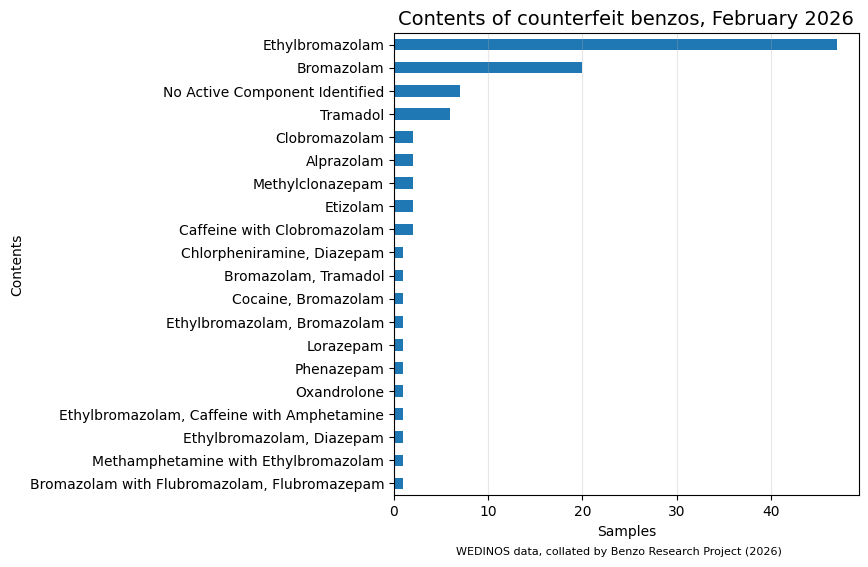

In [36]:
fig, ax = subplots(figsize=(6, 6))
ax.title.set_text('Contents of counterfeit benzos, February 2026')
ax.title.set_fontsize(14)
counterfeitContents.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Samples')
ax.set_ylabel('Contents')
ax.grid(axis='x',alpha=0.3)
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by Benzo Research Project (2026)', 
            horizontalalignment='center', wrap=True, fontsize=8)

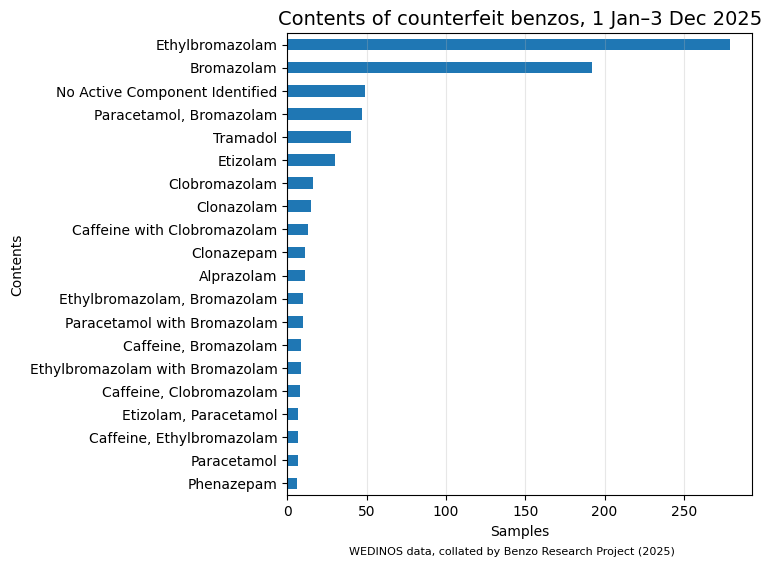

In [163]:
fig, ax = subplots(figsize=(6, 6))
ax.title.set_text('Contents of counterfeit benzos, 1 Jan–3 Dec 2025')
ax.title.set_fontsize(14)
counterfeitContents_all.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Samples')
ax.set_ylabel('Contents')
ax.grid(axis='x',alpha=0.3)
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by Benzo Research Project (2025)', 
            horizontalalignment='center', wrap=True, fontsize=8)

## Plots

In [75]:
plot_totals = np.array([
                            ['Sold as Benzos', total_benzo_intent],
                            ['Counterfeit', total_counterfeit_benzos],
                            ['Not Counterfeit', total_correct_benzos],
                            ['Unknown Intent', unknown_benzos],
                            ['Not Benzos', total_not_benzos]
                        ])
nitazene_totals = np.array([
                            ['Counterfeit opioids', totalnit-wantednit-cbenzo_count-unknownnit],
                            ['Counterfeit benzos', cbenzo_count],
                            ['Intended nitazenes', wantednit],
                            #['Metonitazene-containing benzos', cbenzo_meto_count],
                            ['Unknown intent', unknownnit]
                        ])
    

In [76]:
print(nitazene_totals)

[['Counterfeit opioids' '47']
 ['Counterfeit benzos' '8']
 ['Intended nitazenes' '7']
 ['Unknown intent' '2']]


In [77]:
def monthly_benzo_rates(df, status, year):
    '''
    Creates a 12x3 numpy array with monthly counts of benzos sold as 'status' in the given year.
    Each row corresponds to a month, with the first column being the month number,
    the second column being the count of samples sold as 'status', and the third column being
    the total count of samples sold as benzos in that month.
    '''
    array = np.array([ #Month, Count of samples sold as status,                                                                                  Total samples sold as benzos,                                                               
                        [1, len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['sold_as_benzo'] == '1')])],
                        [2, len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['sold_as_benzo'] == '1')])],
                        [3, len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['sold_as_benzo'] == '1')])],
                        [4, len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['sold_as_benzo'] == '1')])],
                        [5, len(df[(df['date_received'].str.contains(f'May {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'May {year}')) & (df['sold_as_benzo'] == '1')])],
                        [6, len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['sold_as_benzo'] == '1')])],
                        [7, len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['sold_as_benzo'] == '1')])],
                        [8, len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['sold_as_benzo'] == '1')])],
                        [9, len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['sold_as_benzo'] == '1')])],
                        [10, len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['sold_as_benzo'] == '1')])],
                        [11, len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['sold_as_benzo'] == '1')])],
                        [12, len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['sold_as_benzo'] == '1')])]
                    ])
    return array

monthly_data = monthly_benzo_rates(df_benzo_2025, 'counterfeit', 2025)

In [78]:
def benzoMonthlyCounts(df, year, benzoname='Ethylbromazolam'):
    '''Produces a 12x4 array of the number of a given benzo found in samples tested per month in a given dataframe and year.
    Input dataframe, year (e.g., 2025), and the chosen benzo (default 'Ethylbromazolam', case sensitive!).'''
    array = np.array([ #Month, Count of samples sold as ethylbromazolam,                                                                 Total samples containing ethylbromazolam,                                                                                                                                                                                 Total samples sold as benzos,                                                                  
                        [1, len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['sold_as_benzo'] == '1')])],
                        [2, len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['sold_as_benzo'] == '1')])],
                        [3, len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['sold_as_benzo'] == '1')])],
                        [4, len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['sold_as_benzo'] == '1')])],
                        [5, len(df[(df['date_received'].str.contains(f'May {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'May {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'May {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'May {year}')) & (df['sold_as_benzo'] == '1')])],
                        [6, len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['sold_as_benzo'] == '1')])],
                        [7, len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['sold_as_benzo'] == '1')])],
                        [8, len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['sold_as_benzo'] == '1')])],
                        [9, len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['sold_as_benzo'] == '1')])],
                        [10, len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['sold_as_benzo'] == '1')])],
                        [11, len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['sold_as_benzo'] == '1')])],
                        [12, len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['sold_as_benzo'] == '1')])]
                    ])
    return array
ethylmonthly = benzoMonthlyCounts(df_benzo_2025, 2025, benzoname='Ethylbromazolam')
bromazmonthly = benzoMonthlyCounts(df_benzo_2025, 2025, benzoname='Bromazolam')

In [79]:
df_benzo.loc[df_benzo['major'] == "Ethylbromazolam"]

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W073678,13 Feb 2026,SA1,XANEX,XANEX,White,Tablet,Not Stated,Relaxed,Ethylbromazolam,,51.63398,-3.94848
W073817,13 Feb 2026,M28,DIAZEPAM,DIAZEPAM ACCORD 10MG,Blue,Tablet,Not Stated,Not Stated,Ethylbromazolam,,53.506067,-2.399067
W073638,13 Feb 2026,BS5,DIAZEPAM,SAME,Blue,Tablet,Oral,Not Stated,Ethylbromazolam,,51.462,-2.5519
W073460,13 Feb 2026,WF1,Alprazolam,Xanax 2mg,White,Tablet,Oral,"Euphoria, Relaxed, Memory Loss, Confusion, Sui...",Ethylbromazolam,,53.692467,-1.4771
W073462,13 Feb 2026,WF1,Diazepam 10mg,diazepam valium,Blue,Tablet,Not Stated,"Euphoria, Relaxed, Memory Loss",Ethylbromazolam,,53.692467,-1.4771
...,...,...,...,...,...,...,...,...,...,...,...,...
W071398,27 Nov 2025,SW34,DIAZEPAM,DIAZEPAM,Green,Tablet,Oral,"Relaxed, Relaxed, Confusion, Confusion",Ethylbromazolam,,51.487975,-0.165875
W071399,27 Nov 2025,SW34,alprazolam,alprazolam,Blue,Tablet,Oral,"Relaxed, Relaxed, Memory Loss, Memory Loss",Ethylbromazolam,,51.487975,-0.165875
W071150,24 Nov 2025,DD2,CLONAZEPAM,RIVOTRIL 2MG,White,Tablet,Oral,No Effect,Ethylbromazolam,,56.477777,-3.058946
W071594,03 Dec 2025,M44,Diazepam tabs,Not Stated,Blue,Tablet,Oral,"Increased Confidence, Relaxed, Tiredness, Head...",Ethylbromazolam,Bromazolam,53.4425,-2.4232


In [169]:
print(ethylmonthly.shape)

(12, 4)


In [170]:
print(f'{sum(ethylmonthly[:,1])} samples were sold as ethylbromazolam between Jan and Sep 2025.')

0 samples were sold as ethylbromazolam between Jan and Sep 2025.


/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_31499/915090323.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0,20,40,60,80,100],**montfont)


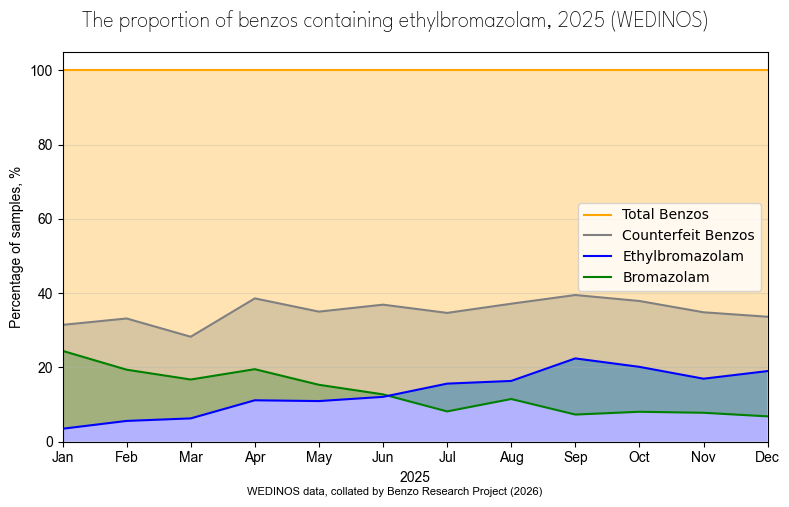

In [80]:
lsfont = {'fontname':'League Spartan',
          'weight': 'semibold'}
montfont = {'fontname':'Arial'}
data_select = monthly_data[monthly_data[:,0] <= 12]
ethylselect = ethylmonthly[ethylmonthly[:,0] <= 12]
bromazselect = bromazmonthly[bromazmonthly[:,0] <= 12]
fig, ax = subplots(figsize=(8, 5))
fig.suptitle('The proportion of benzos containing ethylbromazolam, 2025 (WEDINOS)', fontsize=16, **lsfont)
ax.fill_between(ethylselect[:,0], 0, ethylselect[:,2]/ethylselect[:,3]*100, facecolor='blue', alpha=0.3)
ax.fill_between(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, ethylselect[:,3]/ethylselect[:,3]*100, facecolor='orange', alpha=0.3)
ax.fill_between(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, bromazselect[:,2]/bromazselect[:,3]*100, facecolor='green', alpha=0.3)
ax.fill_between(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, data_select[:,1]/data_select[:,2]*100, facecolor='grey', alpha=0.3)

ax.plot(ethylselect[:,0], ethylselect[:,3]/ethylselect[:,3]*100, label ='Total Benzos', color='orange')
ax.plot(data_select[:,0], data_select[:,1]/data_select[:,2]*100, label ='Counterfeit Benzos', color='gray')
ax.plot(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, label ='Ethylbromazolam', color='blue', zorder=3)
ax.plot(bromazselect[:,0], bromazselect[:,2]/bromazselect[:,3]*100, label ='Bromazolam', color='green')
ax.set_ylabel('Percentage of samples, %', **montfont)
ax.set_xlim(1, 9)
ax.set_ylim(0)
ax.set_xticks(ethylselect[:,0])
ax.set_yticklabels([0,20,40,60,80,100],**montfont)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],**montfont)
ax.grid(axis='y',alpha=0.3)
ax.set_xlabel('2025',**montfont)
ax.legend(loc='right')
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by Benzo Research Project (2026)', 
            horizontalalignment='center', wrap=True, fontsize=8,**montfont)
fig.tight_layout()

In [172]:
monthly_data[:,0]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [173]:
plot_totals[:,1].astype(int)

array([2407,  851, 1549,    7,   77])

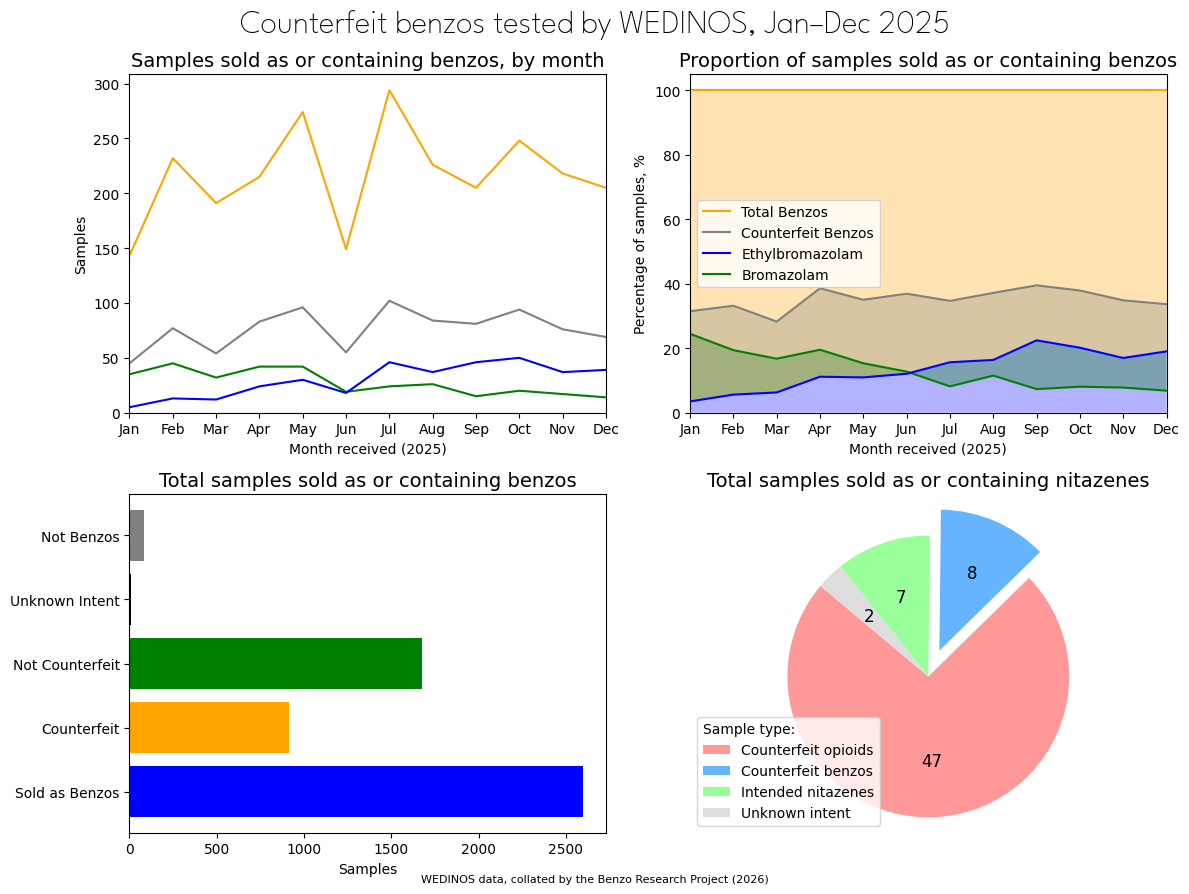

In [ ]:
data_select = monthly_data[monthly_data[:,0] <= 12]
fig, (ax, ax1) = subplots(2, 2, figsize=(12, 9))
fig.suptitle('Counterfeit benzos tested by WEDINOS, Jan–Dec 2025', fontsize=24, **lsfont)
ax[0].set_title('Samples sold as or containing benzos, by month', fontsize=14)
ax[0].plot(data_select[:,0], data_select[:,1], label ='Counterfeit Benzos', color='gray')
ax[0].plot(data_select[:,0], data_select[:,2], label ='Total Benzos', color='orange')
ax[0].plot(bromazselect[:,0], bromazselect[:,2], label ='Bromazolam', color='green')
ax[0].plot(ethylselect[:,0], ethylselect[:,2], label ='Ethylbromazolam', color='blue')
ax[0].set_ylabel('Samples')
ax[0].set_xlim(1, 9)
ax[0].set_ylim(0)
ax[0].set_xlabel('Month received (2025)')
ax[0].set_xticks(data_select[:,0])
ax[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
#ax[0].legend()
ax[1].set_title('Proportion of samples sold as or containing benzos', fontsize=14)
ax[1].fill_between(ethylselect[:,0], 0, ethylselect[:,2]/ethylselect[:,3]*100, facecolor='blue', alpha=0.3)
ax[1].fill_between(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, ethylselect[:,3]/ethylselect[:,3]*100, facecolor='orange', alpha=0.3)
ax[1].fill_between(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, bromazselect[:,2]/bromazselect[:,3]*100, facecolor='green', alpha=0.3)
ax[1].fill_between(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, data_select[:,1]/data_select[:,2]*100, facecolor='grey', alpha=0.3)
ax[1].plot(ethylselect[:,0], ethylselect[:,3]/ethylselect[:,3]*100, label ='Total Benzos', color='orange')
ax[1].plot(data_select[:,0], data_select[:,1]/data_select[:,2]*100, label ='Counterfeit Benzos', color='gray')
ax[1].plot(ethylselect[:,0], ethylselect[:,2]/ethylselect[:,3]*100, label ='Ethylbromazolam', color='blue', zorder=3)
ax[1].plot(bromazselect[:,0], bromazselect[:,2]/bromazselect[:,3]*100, label ='Bromazolam', color='green')
ax[1].set_ylabel('Percentage of samples, %')
ax[1].set_xlim(1, 9)
ax[1].set_ylim(0)
ax[1].set_xlabel('Month received (2025)')
ax[1].set_xticks(data_select[:,0])
ax[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax[1].legend()

ax1[0].set_title('Total samples sold as or containing benzos', fontsize=14)
ax1[0].barh(plot_totals[:,0], plot_totals[:,1].astype(int), color=['blue', 'orange', 'green', 'black', 'grey'])
ax1[0].set_xlabel('Samples')

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_format

ax1[1].set_title('Total samples sold as or containing nitazenes', fontsize=14)
ax1[1].pie(nitazene_totals[:,1].astype(int),
           #labels=nitazene_totals[:3,0], 
           explode=[0, 0.2, 0, 0],
           autopct=autopct_format(nitazene_totals[:,1].astype(int)), #autopct='%1.1f%%' for percentages
           startangle=140, 
           colors=['#ff9999','#66b3ff', '#99ff99', '#dddddd'], 
           textprops={'fontsize': 12})

ax1[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1[1].legend(nitazene_totals[:,0], loc='lower left', title='Sample type:                  ')
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by the Benzo Research Project (2026)', 
            horizontalalignment='center', wrap=True, fontsize=8)
fig.tight_layout()
#fig.savefig('data/Jan-Dec2026_wedinossummary.png',dpi=300)


In [175]:
dfCounterfeitsAll = pd.DataFrame(counterfeitContents_all)
dfCounterfeitsAll

,count
complete contents,
Ethylbromazolam,279
Bromazolam,192
No Active Component Identified,49
"Paracetamol, Bromazolam",47
Tramadol,40
...,...
Trazodone,1
"Flubromazolam, Deschloroetizolam",1
Oxycodone,1


In [49]:
def getUniqueContents(df):
    contents_list = []
    for i in df.index:
        if (', ' not in i) and (' with ' not in i):
            contents_list.append(i)
        else:
            if ' with ' in i:
                i_list = i.split(' with ')
                for j in i_list:
                    if ', ' in j:
                        j = j.split(', ')
                        for k in j:
                            contents_list.append(k)
                    else:
                        contents_list.append(j)
            if ', ' in i:
                i_list = i.split(', ')
                for j in i_list:
                    if ' with ' in j:
                        j = j.split(' with ')
                        for k in j:
                            contents_list.append(k)
                    else:
                        contents_list.append(j)
    uniqueContents = list(set(contents_list))

    contentsDict = dict.fromkeys(uniqueContents)
    contentsDict = {key: 0 for key in contentsDict}
    for idx, row in df.iterrows():
        for i in uniqueContents:
            if i in idx:
                contentsDict[i] = contentsDict[i]+int(row['count'])
    uniqueCounts = pd.DataFrame(contentsDict.items(), columns=['Compound','Count']).set_index('Compound').sort_values('Count', ascending=False)
    return uniqueCounts

In [52]:
getUniqueContents(pd.DataFrame(counterfeitContents))

,Count
Compound,
Ethylbromazolam,30
Bromazolam,9
Metonitazene,3
Methylclonazepam,2
Caffeine,2
Temazepam,2
Clonazolam,1
Rilmazafone,1
Clobromazolam,1


In [ ]:
uniqueCounterfeitCounts = getUniqueContents(dfCounterfeitsAll)
uniqueCounterfeitCounts


,Count
Compound,
Ethylbromazolam,309
Bromazolam,294
Paracetamol,77
Caffeine,49
No Active Component Identified,49
Tramadol,43
Etizolam,41
Clobromazolam,40
Clonazolam,15


In [184]:
dfContents_all = pd.DataFrame(getContents(df_benzo))
uniqueAllCounts = getUniqueContents(dfContents_all)
uniqueAllCounts

,Count
Compound,
Diazepam,988
Ethylbromazolam,325
Bromazolam,319
Alprazolam,285
Clonazepam,208
...,...
Cyproheptadine,1
desalkylflurazepam,1
Desalkyligidazepam,1


In [178]:
contentsDict = dict.fromkeys(uniqueContents)
contentsDict = {key: 0 for key in contentsDict}
for idx, row in dfCounterfeitsAll.iterrows():
    for i in uniqueContents:
        if i in idx:
            contentsDict[i] = contentsDict[i]+int(row['count'])
uniqueCounts = pd.DataFrame(contentsDict.items(), columns=['Compound','Count']).set_index('Compound').sort_values('Count', ascending=False)

In [179]:
uniqueCounts

,Count
Compound,
Ethylbromazolam,309
Bromazolam,294
Paracetamol,77
Caffeine,49
No Active Component Identified,49
Tramadol,43
Etizolam,41
Clobromazolam,40
Clonazolam,15


In [120]:
if 'Ethylbromazolam' in dfCounterfeitsAll.index:
    print('hi')

hi


In [374]:
nitazene_totals[:3,1].astype(int)

array([41,  5,  1])

In [358]:
nitazene_totals[:3,0]

array(['Other counterfeits', 'Counterfeit benzos', 'Sold as nitazenes'],
      dtype='<U30')

In [330]:
msjb_count=0
total=0
for idx, row in df_benzo.iterrows():
    if ('bensedin' in str.lower(row['intent'])) or ('msj' in str.lower(row['intent'])) or ('benzodine' in str.lower(row['intent'])):
        msjb_count+=1
        total+=1
    else:
        total+=1
print(msjb_count,'intended as MSJ/Bensedin/Benzodine')
print(100*msjb_count/total,'%')

47 intended as MSJ/Bensedin/Benzodine
2.365374937091092 %


## Processing cleaned WEDINOS data

In [1]:
def find_benzos_in_cleaned(df_benzo):
    for idx, row in df_benzo.iterrows():
        if any(substring in str.lower(row['Purchase']) for substring in benzo_substring_list):
            sold_as_benzo='1'
            try: # try-except to avoid errors with missing testing data
                if (str.lower(row['Result 1']) in str.lower(row['Purchase'])) or (str.lower(row['Purchase']) in str.lower(row['Result 1'])):
                    status='not counterfeit'
                elif ('unable to identify' in str.lower(row['Result 1'])):
                    status='inconclusive'
                # checking diazepam spellings
                elif any(substring in str.lower(row['Purchase']) for substring in diazepam_substring_list):
                    if ('diazepam' in str.lower(row['Result 1'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                # checking xanax spellings
                elif any(substring in str.lower(row['Purchase']) for substring in alprazolam_substring_list):
                    if ('alprazolam' in str.lower(row['Result 1'])):
                        status='not counterfeit'    
                    else:
                        status='counterfeit'
                # checking clonazepam spellings
                elif any(substring in str.lower(row['Purchase']) for substring in clonazepam_substring_list):
                    if ('clonazepam' in str.lower(row['Result 1'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                elif ('benzo' in str.lower(row['Purchase'])):
                    if any(substring in str.lower(row['Purchase']) for substring in diazepam_substring_list):
                        if ('diazepam' in str.lower(row['Result 1'])):
                            status='not counterfeit'
                        else:
                            status='counterfeit'
                    elif any(substring in str.lower(row['Purchase']) for substring in benzo_substring_list):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                else:
                    status='counterfeit'
                    #print(row['intent'],': ',row['major'],'with',row['minor'])
            except:
                status='inconclusive'
        else:
            sold_as_benzo='0'
        
        df_benzo.loc[idx,'sold_as_benzo'] = sold_as_benzo
        df_benzo.loc[idx,'status'] = status

    return df_benzo


In [22]:
aug_cleaned = pd.read_excel('/Users/ajmartin/Downloads/WEDINOS August 2025.xlsx')

In [23]:
augCleaned = find_benzos_in_cleaned(aug_cleaned)
augCleaned

,Key,CtlReceipt,Purchase,SampleForm,Colour,RpAge,RpGender,Postcode,Country,Consumption,...,Result 2,Result 3,Result 4,Result 5,Result 6,Result 7,Result 8,Result 9,sold_as_benzo,status
0,57849,2025-08-01,Diazepam,Tablet,Yellow,Not Stated,Male,TN16,England,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,not counterfeit
1,57850,2025-08-01,Cocaine,Powder,White,50,Male,EH21,Scotland,Not Stated,...,Norcocaine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
2,57851,2025-08-01,Tramadol,Tablet,White,40,Female,BA6,England,Oral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
3,57852,2025-08-01,Tramadol,Tablet,White,40,Female,BA6,England,Oral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
4,57853,2025-08-01,Ketamine,Powder,White,Not Stated,Male,CF48,Wales,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,58592,2025-08-28,Alprazolam,Tablet,White,23,Not Stated,PH22,Scotland,Not Stated,...,Bromazolam,Tramadol,NaN,NaN,NaN,NaN,NaN,NaN,1,counterfeit
651,58593,2025-08-28,MDMA,Tablet,NaN,23,Not Stated,PH22,Scotland,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,counterfeit
652,58594,2025-08-28,Diazepam,Tablet,Blue,43,Male,SK13,England,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,not counterfeit
653,58595,2025-08-28,Diazepam,Tablet,White,26,Male,BS43,England,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,not counterfeit


36.33587786259542% of samples in August 2025 were sold as benzos (238 out of 655), of which:
- 145 contained what they were sold as (60.924369747899156%)
- 93 were counterfeit (39.075630252100844%)


Text(0.5, 1.0, 'Samples intended/sold as benzos tested by WEDINOS, August 2025')

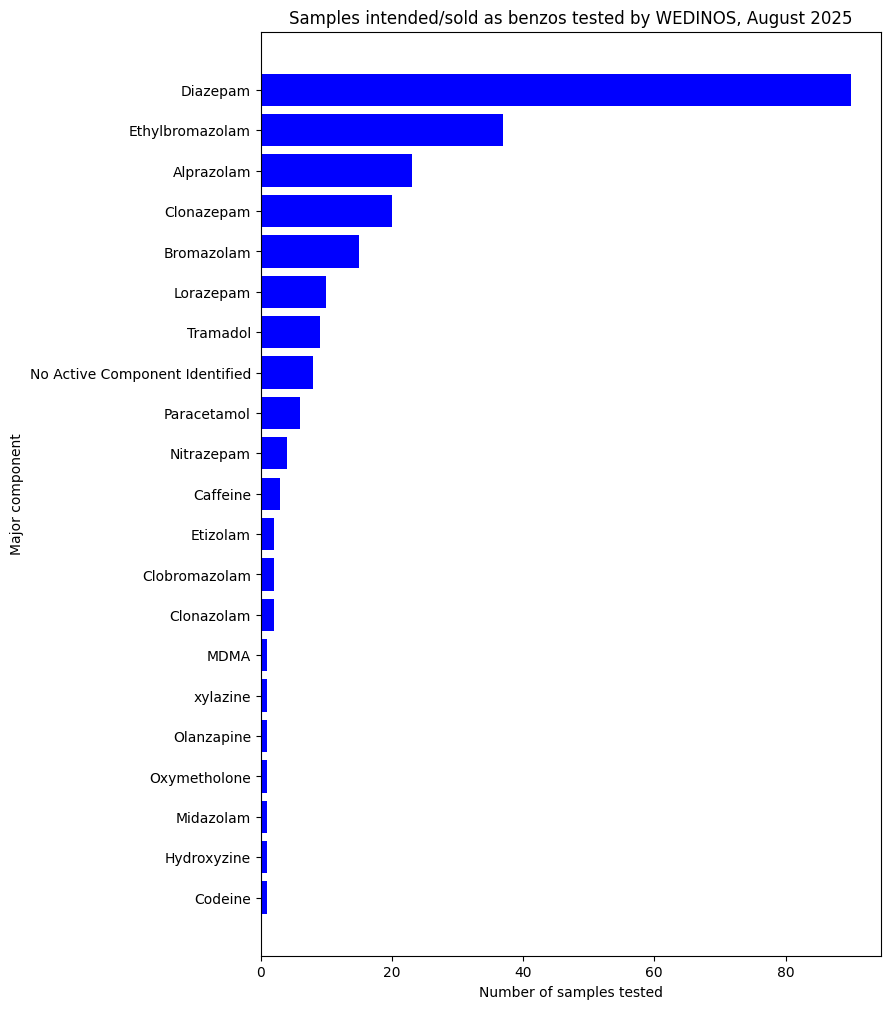

In [41]:
print(f'{100*len(augCleaned[augCleaned["sold_as_benzo"] == "1"])/len(augCleaned)}% of samples in August 2025 were sold as benzos ({len(augCleaned[augCleaned["sold_as_benzo"] == "1"])} out of {len(augCleaned)}), of which:')
print(f'- {len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "not counterfeit")])} contained what they were sold as ({100*len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "not counterfeit")])/len(augCleaned[augCleaned["sold_as_benzo"] == "1"])}%)')
print(f'- {len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "counterfeit")])} were counterfeit ({100*len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "counterfeit")])/len(augCleaned[augCleaned["sold_as_benzo"] == "1"])}%)')
fig, ax = subplots(figsize=(8, 12))
ax.barh(augCleaned[augCleaned["sold_as_benzo"] == "1"]["Result 1"].value_counts().index, augCleaned[augCleaned["sold_as_benzo"] == "1"]["Result 1"].value_counts().values, color='blue')
ax.set_ylabel('Major component')
ax.set_xlabel('Number of samples tested')
fig.gca().invert_yaxis()
ax.set_title('Samples intended/sold as benzos tested by WEDINOS, August 2025')

## Tests (ignore)

In [22]:
from datetime import datetime
for idx, row in df.iterrows():
    df.at[idx, row['date_received']] = datetime.strptime(row['date_received'], '%d %b %Y').date()
print(df['date_received'])

W059957      26 Nov 2024
000230437    21 Nov 2024
W059740      19 Nov 2024
000233224    14 Nov 2024
W059583      14 Nov 2024
                ...     
W046706      10 Jan 2024
W044688      04 Jan 2024
000040892    04 Jan 2024
W044755      22 Dec 2023
W044679      21 Dec 2023
Name: date_received, Length: 144, dtype: object


In [34]:
timeex = datetime.strptime('26 Nov 2024', '%d %b %Y').date()
int(timeex.strftime('%d%b%Y'))


ValueError: invalid literal for int() with base 10: '26Nov2024'

In [35]:
datetime.strptime('Feb','%b').tm_mon

AttributeError: 'datetime.datetime' object has no attribute 'tm_mon'

In [40]:
import calendar
astring = '26 Nov 2024'
def month_number(astring):
    # Convert the string to a datetime object
    month = datetime.strptime(astring, '%d %b %Y').month
    return month
type(month_number(astring))

int

In [50]:
year2 = pd.to_datetime(astring).year
year2

2024

In [71]:
for idx, row in df.iterrows():
    print(row['date_received'])
    df.loc[idx,'date_received'] = pd.Timestamp(row['date_received'])
numdate = row['date_received']
type(df['date_received'].unique()[0])

2024-11-26 00:00:00
2024-11-21 00:00:00
2024-11-19 00:00:00
2024-11-14 00:00:00
2024-11-14 00:00:00
2024-11-20 00:00:00
2024-11-12 00:00:00
2024-11-05 00:00:00
2024-11-05 00:00:00
2024-10-22 00:00:00
2024-10-15 00:00:00
2024-10-11 00:00:00
2024-10-01 00:00:00
2024-09-03 00:00:00
2024-08-28 00:00:00
2024-08-28 00:00:00
2024-08-23 00:00:00
2024-08-20 00:00:00
2024-08-20 00:00:00
2024-08-20 00:00:00
2024-08-20 00:00:00
2024-08-15 00:00:00
2024-08-15 00:00:00
2024-08-07 00:00:00
2024-08-01 00:00:00
2024-08-01 00:00:00
2024-07-29 00:00:00
2024-07-23 00:00:00
2024-07-22 00:00:00
2024-07-16 00:00:00
2024-07-16 00:00:00
2024-07-11 00:00:00
2024-07-09 00:00:00
2024-07-09 00:00:00
2024-07-09 00:00:00
2024-07-02 00:00:00
2024-07-02 00:00:00
2024-07-02 00:00:00
2024-06-18 00:00:00
2024-06-18 00:00:00
2024-06-18 00:00:00
2024-06-18 00:00:00
2024-06-11 00:00:00
2024-06-11 00:00:00
2024-06-10 00:00:00
2024-06-10 00:00:00
2024-06-10 00:00:00
2024-06-07 00:00:00
2024-06-04 00:00:00
2024-06-03 00:00:00


pandas._libs.tslibs.timestamps.Timestamp